__Processing & Analysis of $^{214}\text{Bi}$-MC Files__

__HAY UN GRAN CAMBIO EN LA FORMA DE HACER ESTO, ACTUALIZAR DESCRIPCIÓN__.

Pau has produced MC samples of $^{214}\text{Bi}$ decays in different volumes of the detector.
<br>
We are interested in:
- How many electrons coming from the $^{214}\text{Bi}$ @ cathode end up being fiducials.
- Energy specturm of fiducial electrons induced by $^{214}\text{Bi}$.
<!-- end of the list -->
This notebook has the following four main parts:
- In _Preliminary_ you configure the type of analysis (_cathode_ or _all_) and its corresponding parameters for subsequent processing.
- There is a _Validation Zone_ where all the interesting actions in the processing are inspected in detail.
- All the processing of an entire set of MCs is applied in _Processing_.
- In _Analysis_, we apply $nS2 = 1$ cut and detector region tagging. Then, we define the input processed files for the _Spectrums_ (plotting purposes) and _ROI & Background Index_ analysis,
  <br>
  where we compute the important numbers such as rates, back. index, efficiencies.

__IMPORTANT__: Define in _Preliminary_ all the configuration needed for the use of this notebook.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis')

from libs import bckg_functions as bf
from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

from datetime import datetime
import glob
from invisible_cities.reco.corrections import read_maps
from invisible_cities.reco.corrections import apply_all_correction
from invisible_cities.types.symbols    import NormStrategy
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.offsetbox import (OffsetImage, AnnotationBbox)
import numpy as np
import os
import pandas as pd
from pathlib import Path
from PIL import Image
import scipy

# Styling Plot
pt.ccortesp_plot_style()
PRELIM_LOGO = np.asarray(Image.open('/lhome/ific/c/ccortesp/Analysis/images/next_logo_preliminary.png'))

%matplotlib inline
%load_ext autoreload
%autoreload 2

## Preliminary

In [2]:
# ----- Type of Analysis ----- #
ANALYSIS_TYPE = 'All'                       # Options: 'All', 'Cathode'
DATE = datetime.now().strftime('%d%m%Y')        # Current Date
# DATE = '01122025'                             # Specific Date

In [3]:
# --------------------------------------------
# 1. MC DIRECTORIES, PATHS, KEYS AND FILENAMES
# --------------------------------------------
MC_PATHS = []
if ANALYSIS_TYPE == 'All':

    MC_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/'
    # Iterate over isotopes
    for iso in ['Bi214', 'Tl208', 'K40', 'Co60']:
        ISO_DIR = MC_DIR + iso + '/'
        # Get all subfolders in MC_DIR
        VOLUMES = [folder for folder in os.listdir(ISO_DIR) if os.path.isdir(os.path.join(ISO_DIR, folder))]
        for volume in sorted(VOLUMES):
            # Get all sophronia files in the volume subfolder
            sophronia_files = sorted(glob.glob(os.path.join(ISO_DIR, volume, 'sophronia', '*.sophronia.h5')))
            # print(f"  Found {len(sophronia_files)} sophronia files in {volume}")
            if sophronia_files:
                MC_PATHS.extend(sophronia_files)
            else:
                print(f"No sophronia files found in {volume} for isotope {iso}.")
    # Sort the final list of paths
    MC_PATHS = sorted(MC_PATHS)
    print(f"Total sophronia files to process: {len(MC_PATHS)}")

elif ANALYSIS_TYPE == 'Cathode':

    MC_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/NEXT/MC/NEXT100/Radiogenics/LPR/IC_v2.3.1/NEXUS_v7_09_00/Bi214/CATHODE_SURF/sophronia/'
    MC_PATHS = sorted(glob.glob(MC_DIR + '*.sophronia.h5'))
    print(f"Total sophronia files to process: {len(MC_PATHS)}")

else:
    
    raise ValueError("Invalid ANALYSIS_TYPE. Choose 'All' or 'Cathode'.")

# KEYS
NEXUS_KEY = '/MC/configuration'
DORO_KEY = '/DST/Events'
SOPH_KEY = '/RECO/Events'

# COLIUMNS TO USE
doro_columns = ['event', 'time', 'nS1', 'nS2', 'S1h', 'S1e', 'S2e', 'S2q', 'DT', 'X', 'Y', 'Z']
soph_columns = ['event', 'time', 'npeak', 'X', 'Xpeak', 'Y', 'Z', 'Q', 'Ec']

# OUTPUT
OUTPUT_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/'
OUTPUT_H5  = 'processed_MC_background_' + ANALYSIS_TYPE + '_' + DATE + '.h5'
print(f"Output will be saved to: {os.path.join(OUTPUT_DIR, OUTPUT_H5)}")

# ------------------------
# 2. PROCESSING PARAMETERS
# ------------------------
V_DRIFT = 0.865     # Drift velocity in [mm/μs]

# --- S1 Signal Cuts ---
# Po-like events are filtered using: S1h >= m * S1e + b
M_NOPOLIKE = 0.17
B_NOPOLIKE = -56

# --- Hits Clusterizer Configuration ---
CLUSTER_CONFIG = {"eps": 3, "min_samples": 5}

# --- S1e Correction ---
DT_STOP = 1372.2543          # Cathode temporal position in [μs]
CV_FIT  = [0.57, 796.53]     # Fit values for S1e correction vs DT

# --- Trigger 2 Efficiency ---
# Events with event-level energy below this are removed to account for trigger efficiency.
TRG2_THRESHOLD = 0.5         # in [MeV]

# -------------------
# 3. DETECTOR REGIONS
# -------------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

No sophronia files found in CATHODE_SURF for isotope Tl208.
No sophronia files found in ANODE_RING for isotope K40.
No sophronia files found in CATHODE_RING for isotope K40.
No sophronia files found in CATHODE_SURF for isotope K40.
No sophronia files found in GATE_RING for isotope K40.
No sophronia files found in HDPE_TUBE for isotope K40.
No sophronia files found in ANODE_RING for isotope Co60.
No sophronia files found in CATHODE_RING for isotope Co60.
No sophronia files found in CATHODE_SURF for isotope Co60.
No sophronia files found in GATE_RING for isotope Co60.
No sophronia files found in HDPE_TUBE for isotope Co60.
No sophronia files found in ICS for isotope Co60.
No sophronia files found in SHIELDING_LEAD for isotope Co60.
No sophronia files found in TP_COPPER_PLATE for isotope Co60.
Total sophronia files to process: 64191
Output will be saved to: /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/processed_MC_background_All_02012026.h5


# Processing

### Functions

In [18]:
# Helper function
def aggregate_to_event_level(df_soph: pd.DataFrame, df_doro: pd.DataFrame) -> pd.DataFrame:
    """
    Aggregates hit-level data to event-level summary data.
    """
    if df_soph.empty:
        return pd.DataFrame()

    # ----- Dorothea Aggregation ----- #
    doro_agg_dict = {
                        'nS1': ('nS1', 'max'),
                        'nS2': ('nS2', 'max'),
                        'S1e_max': ('S1e', 'max'),
                        'S1e_corr_max': ('S1e_corr', 'max'),
                    }
    doro_agg_df = df_doro.groupby('event', as_index=False).agg(**doro_agg_dict)
    # ----- Sophronia Aggregation ----- #
    soph_agg_dict = {
                        'time': ('time', 'mean'),
                        'X_bary': ('X', lambda x: bf.weighted_avg(x, df_soph.loc[x.index, 'Ec'])),
                        'Y_bary': ('Y', lambda y: bf.weighted_avg(y, df_soph.loc[y.index, 'Ec'])),
                        'Z_bary': ('Z', lambda z: bf.weighted_avg(z, df_soph.loc[z.index, 'Ec'])),
                        'Z_min': ('Z', 'min'),
                        'Z_max': ('Z', 'max'),
                        'R_max': ('X', lambda g: bf.R_max_func(df_soph.loc[g.index])),
                        'E_evt_mev': ('Ec', 'sum'),
                        'n_cluster_max': ('cluster', 'max')
                    }

    # Perform aggregation
    df_file = df_soph.groupby('event', as_index=False).agg(**soph_agg_dict)
    df_file = pd.merge(df_file, doro_agg_df, on='event', how='left')

    return df_file

# ----- Process Function ----- #

def process_mc_file(h5_path):
    """
    Processes a single Monte Carlo HDF5 file.
    Reads data, applies cuts, aggregates, and returns results.
    """
    h5_path = Path(h5_path)
    # print(f"→ Processing file: {h5_path}\n")

    # Event counters for this file
    counts = {
                'Generated': 0, 'IC_Reco': 0, 'Strong_S2': 0, 'E_Positive': 0,
                'S1_Cut': 0, 'ns1_zero': 0, 'ns1_one': 0
    }

    # ----- Load Dataframes ----- #
    try:
        # Nexus
        df_nexus = pd.read_hdf(h5_path, key=NEXUS_KEY)
        gen_evts_series = df_nexus.loc[df_nexus['param_key'] == 'num_events', 'param_value']
        if not gen_evts_series.empty:
            counts['Generated'] = int(gen_evts_series.values[0])      # Count of generated events
        # Dorothea
        df_dorothea = pd.read_hdf(h5_path, key=DORO_KEY).loc[:, doro_columns]
        # Sophronia
        df_sophronia = pd.read_hdf(h5_path, key=SOPH_KEY).loc[:, soph_columns]
        counts['IC_Reco'] = df_sophronia['event'].nunique()        # Count of reconstructed events
    except KeyError as e:
        print(f"Key {e} not found in {h5_path.name}. Skipping file.")
        return None
    
    # ----- Data Cleaning ----- #
    # Remove weak S2 peaks in Dorothea and Sophronia
    df_dorothea  = df_dorothea[df_dorothea['S2q'] >= 0].copy()
    df_sophronia = df_sophronia[df_sophronia['Xpeak'] >= -5000].copy()
    evts_after_clean = df_sophronia['event'].unique()
    counts['Strong_S2'] = len(evts_after_clean)
    df_dorothea = df_dorothea[df_dorothea['event'].isin(evts_after_clean)].copy()       # Update dataframe

    # ----- Energy Correction ----- #
    # Set hits with NaN or negative energy to 0
    df_sophronia['Ec'] = np.where(pd.notna(df_sophronia['Ec']) & (df_sophronia['Ec'] > 0), df_sophronia['Ec'], 0)
    positive_Ec_events = df_sophronia['event'].unique()
    counts['E_Positive'] = len(positive_Ec_events)
    df_dorothea, df_sophronia = bf.apply_cut_and_update(df_dorothea, df_sophronia, event_ids=positive_Ec_events)

    # ----- S1e Cut & Correction ----- #
    # nS1 <= 1 (NO-Polike)
    counts['ns1_zero'] = df_dorothea.loc[df_dorothea['nS1'] == 0, 'event'].nunique()
    counts['ns1_one']  = df_dorothea.loc[df_dorothea['nS1'] == 1, 'event'].nunique()
    s1_mask = (df_dorothea['nS1'] == 0) | (df_dorothea['nS1'] == 1)
    df_dorothea, df_sophronia = bf.apply_cut_and_update(df_dorothea, df_sophronia, cut_mask=s1_mask, df_for_mask=df_dorothea)
    counts['S1_Cut'] = df_sophronia['event'].nunique()
    # S1e Correction (NO mandatory)
    df_dorothea = crudo.correct_S1e(df_dorothea, CV_FIT, DT_STOP, output_column='S1e_corr')     # Based on alpha analysis

    # If there is no data left after cuts, return empty dataframes
    if df_sophronia.empty:
        return {'processed_df': pd.DataFrame(), 'counts': counts}

    # ----- Topology Information ----- #
    # DBSCAN
    cluster_tagger = crudo.hits_clusterizer(**CLUSTER_CONFIG)
    df_sophronia = cluster_tagger(df_sophronia)
    # events_with_secondary_tracks = df_sophronia.loc[df_sophronia['cluster'] > 0, 'event'].unique()    
    
    # ----- Dataframe @ Event-Level ----- #
    df_event = aggregate_to_event_level(df_sophronia, df_dorothea)
    
    # ----- Monte Carlo Information ----- #
    isotope = h5_path.parts[-4]
    volume  = h5_path.parts[-3]
    df_event['isotope'] = isotope
    df_event['volume']  = volume

    return {'processed_df': df_event, 'counts': counts}

## Execution

In [6]:
# Event counters
Total_gen   = 0
Total_reco  = 0   
Total_strong_S2 = 0
Total_E_positive = 0
Total_S1 = 0;   Total_nS1_zero  = 0;    Total_nS1_one   = 0

# Store all the processed dfs
all_processed_dfs = []
# all_sophronia_dfs = []

# ----- Parallel Processing ----- #
print(f"----- Processing {len(MC_PATHS)} files in parallel -----")
results = Parallel(n_jobs=-1, verbose=2)(
    delayed(process_mc_file)(h5_path) for h5_path in MC_PATHS
)
print("Processing complete.")

# ----- Collect Results ----- #
valid_results = [r for r in results if r is not None]       # Filter out None results
all_processed_dfs = [res['processed_df'] for res in valid_results if not res['processed_df'].empty]
# all_sophronia_dfs = [res['sophronia_df'] for res in valid_results if not res['sophronia_df'].empty]

# ----- Concatenation ----- #
final_mc_df   = pd.concat(all_processed_dfs, ignore_index=True) if all_processed_dfs else pd.DataFrame()
# final_soph_df = pd.concat(all_sophronia_dfs, ignore_index=True) if all_sophronia_dfs else pd.DataFrame()
# ----- Aggregate Counters ----- #
for res in valid_results:
    counts = res['counts']
    Total_gen        += counts['Generated']
    Total_reco       += counts['IC_Reco']
    Total_strong_S2  += counts['Strong_S2']
    Total_E_positive += counts['E_Positive']
    Total_S1        += counts['S1_Cut']
    Total_nS1_zero  += counts['ns1_zero']
    Total_nS1_one   += counts['ns1_one']

# ----- Final Verbosity ----- #
print("\n--- Processing Summary ---")
print(f"Total generated events                = {Total_gen} ({Total_gen/Total_gen:.2%})")
print(f"Total events after reco chain         = {Total_reco} ({Total_reco/Total_gen:.2%})")
print(f"Total events with strong S2           = {Total_strong_S2} ({Total_strong_S2/Total_reco:.2%})")
print(f"Total events after positive E cut     = {Total_E_positive} ({Total_E_positive/Total_strong_S2:.2%})")
print(f"Total events after nS1 cut            = {Total_S1} ({Total_S1/Total_E_positive:.2%})")
print(f"    - of which nS1 = 0 ¬ {Total_nS1_zero} ({Total_nS1_zero/Total_E_positive:.2%})")
print(f"    - of which nS1 = 1 ¬ {Total_nS1_one} ({Total_nS1_one/Total_E_positive:.2%})")

print('\nY ya, eso es todo, eso es todo ♥')

----- Processing 64191 files in parallel -----


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 192 concurrent workers.


[Parallel(n_jobs=-1)]: Done 264 tasks      | elapsed:   10.1s
[Parallel(n_jobs=-1)]: Done 629 tasks      | elapsed:   10.9s
[Parallel(n_jobs=-1)]: Done 1074 tasks      | elapsed:   13.0s
[Parallel(n_jobs=-1)]: Done 1601 tasks      | elapsed:   17.2s
[Parallel(n_jobs=-1)]: Done 2208 tasks      | elapsed:   21.7s
[Parallel(n_jobs=-1)]: Done 2897 tasks      | elapsed:   26.8s
[Parallel(n_jobs=-1)]: Done 3666 tasks      | elapsed:   32.3s
[Parallel(n_jobs=-1)]: Done 4517 tasks      | elapsed:   38.6s
[Parallel(n_jobs=-1)]: Done 5448 tasks      | elapsed:   45.2s
[Parallel(n_jobs=-1)]: Done 6461 tasks      | elapsed:   50.3s
[Parallel(n_jobs=-1)]: Done 7554 tasks      | elapsed:  1.0min
[Parallel(n_jobs=-1)]: Done 8729 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done 9984 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 11321 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done 12738 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done 14237 tasks      | elapsed:

Key 'No object named /MC/configuration in the file' not found in Bi214_BUBBLE_SEAL_NEXT100_0003.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_BUBBLE_SEAL_NEXT100_0191.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_BUBBLE_SEAL_NEXT100_0365.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_BUBBLE_SEAL_NEXT100_0548.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_BUBBLE_SEAL_NEXT100_0731.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_BUBBLE_SEAL_NEXT100_0914.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_EDPM_SEAL_NEXT100_0045.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_PEDESTAL_NEXT100_0083.sophronia.h5. Skipping file.
Key '

[Parallel(n_jobs=-1)]: Done 31368 tasks      | elapsed:  3.6min


...

Key 'No object named /MC/configuration in the file' not found in Bi214_EDPM_SEAL_NEXT100_0071.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_SHIELDING_LEAD_NEXT100_2252.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_SHIELDING_LEAD_NEXT100_2596.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_SHIELDING_STRUCT_NEXT100_0549.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_SHIELDING_STRUCT_NEXT100_1319.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Bi214_SHIELDING_STRUCT_NEXT100_1497.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Co60_BUBBLE_SEAL_NEXT100_0027.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in Co60_PEDESTAL_NEXT100_0000.sophronia.h5. S

[Parallel(n_jobs=-1)]: Done 58098 tasks      | elapsed:  5.0min


Key 'No object named /MC/configuration in the file' not found in K40_EDPM_SEAL_NEXT100_0365.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in K40_PEDESTAL_NEXT100_0062.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in K40_PEDESTAL_NEXT100_0161.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in K40_PEDESTAL_NEXT100_0324.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in K40_PEDESTAL_NEXT100_0489.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in K40_PEDESTAL_NEXT100_0653.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in K40_PEDESTAL_NEXT100_0823.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration in the file' not found in K40_PEDESTAL_NEXT100_0984.sophronia.h5. Skipping file.
Key 'No object named /MC/configuration 

[Parallel(n_jobs=-1)]: Done 61217 tasks      | elapsed:  5.4min
[Parallel(n_jobs=-1)]: Done 64191 out of 64191 | elapsed:  6.9min finished


Processing complete.

--- Processing Summary ---
Total generated events                = 9329175721 (100.00%)
Total events after reco chain         = 3383758 (0.04%)
Total events with strong S2           = 3383758 (100.00%)
Total events after positive E cut     = 3383758 (100.00%)
Total events after nS1 cut            = 3374200 (99.72%)
    - of which nS1 = 0 ¬ 111827 (3.30%)
    - of which nS1 = 1 ¬ 3262373 (96.41%)

Y ya, eso es todo, eso es todo ♥


## Detector Region Tagging

We define a _global event ID_, 'cause we can have repeated _event ID_ across different isotopes and volumes
<br>
Additionally, we copy this information along isotope/volume tags into hits dataframe

In [8]:
for dataframe in [final_mc_df]:
    # An original event is defined as a row in dataframe where at least one of the columns 
    # ('event', 'Isotope', 'Volume') differs from the corresponding row below it (using `shift`).
    event_OG = (dataframe[['event', 'isotope', 'volume']] != dataframe[['event', 'isotope', 'volume']].shift())

    # If any column in event_OG is True, it means the row corresponds to the start of a new original event block.
    new_event_block = event_OG.any(axis=1)

    # Use `cumsum()` on the boolean mask to create a unique identifier for each contiguous block of hits 
    # that belong to the same original event.
    unique_block_id = new_event_block.cumsum()

    # Assign a unique global event ID to each block of original events.
    # The `factorize` function generates a unique integer code for each unique block ID.
    dataframe['global_event'] = pd.factorize(unique_block_id)[0]
    print(f"{dataframe['global_event'].nunique()} unique global events identified.")

# Counter
processed_evts = final_mc_df['global_event'].nunique()

3374200 unique global events identified.


In [9]:
# Backup first!
backup_event_df = final_mc_df.copy()
# Now tag by detector region
final_mc_df = bf.tag_event_by_detector_region(final_mc_df, z_cut_low=Z_LOW, z_cut_high=Z_UP, r_cut_high=R_UP, event_column='global_event')
final_mc_df

,event,time,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_mev,n_cluster,nS1,nS2,S1e,S1e_corr,isotope,volume,global_event,region
0,0,1.253990e+06,-344.062292,-165.221148,33.491546,15.618709,44.207833,438.390558,0.402713,1,1,2,154.0,301.240324,Bi214,ANODE_RING,0,anode
1,1,2.387403e+06,-126.622985,-96.187692,786.343249,20.197641,1122.937601,421.680941,0.439779,2,1,3,214.0,416.544628,Bi214,ANODE_RING,1,anode
2,2,4.019228e+06,-289.211259,-104.123245,94.026652,45.461306,172.613587,384.056033,1.228004,0,1,1,404.0,760.200979,Bi214,ANODE_RING,2,fiducial
3,4,8.671749e+06,54.690894,303.960486,224.723701,144.440472,270.774260,373.793521,0.611557,1,1,2,224.0,394.683128,Bi214,ANODE_RING,3,fiducial
4,6,1.259170e+07,-44.761349,-97.411481,258.288332,206.304826,307.595215,356.693883,0.567312,2,1,2,219.0,360.642406,Bi214,ANODE_RING,4,fiducial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3374195,278236187,5.564724e+14,-260.354804,362.486473,1059.216512,1033.809908,1117.033455,507.585595,0.580245,0,1,1,335.0,357.011913,Tl208,VESSEL,3374195,tube
3374196,278236188,5.564724e+14,151.612927,-16.482253,1001.510359,985.971653,1020.127635,492.398285,0.540298,0,1,1,289.0,314.030945,Tl208,VESSEL,3374196,tube
3374197,278236189,5.564724e+14,-214.016929,-288.520026,1109.927903,1044.224134,1196.774284,453.852373,1.733368,0,1,1,941.0,997.839745,Tl208,VESSEL,3374197,cathode
3374198,278236190,5.564724e+14,-211.426971,-169.995783,761.617507,367.558851,951.444289,502.611178,1.941659,1,1,2,1007.0,1522.486903,Tl208,VESSEL,3374198,tube


Check some event displays! ;)))

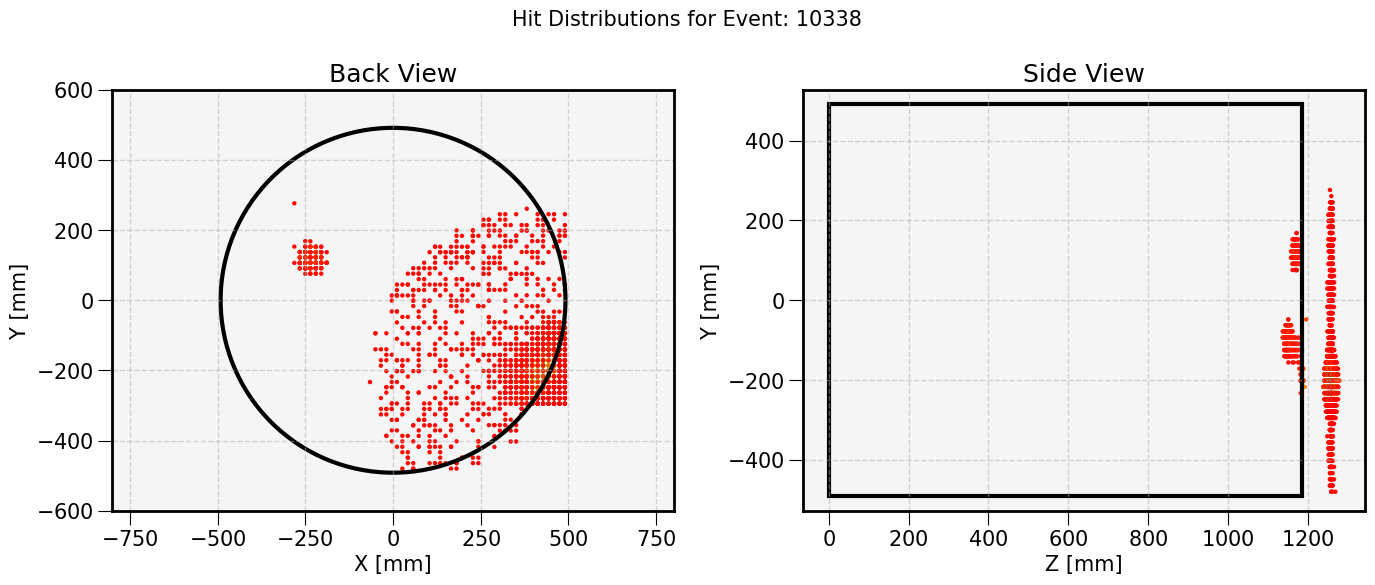

In [16]:
pt.event_display(final_soph_df, variable='Ec', event_column='global_event', event=10338)

## Output
Let's store the final dataframe as an HDF5 file

In [ ]:
# Renombrar columnas en un DataFrame
df = df.rename(columns={
    'S1e': 'S1e_max',
    'S1e_corr': 'S1e_corr_max'
})

# O usando inplace=True para modificar el DataFrame directamente
df.rename(columns={
    'S1e': 'S1e_max',
    'S1e_corr': 'S1e_corr_max'
}, inplace=True)

In [19]:
final_mc_df = final_mc_df.rename(columns={'n_cluster': 'n_cluster_max'
})


In [20]:
final_mc_df

,event,time,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_mev,n_cluster_max,nS1,nS2,S1e_max,S1e_corr_max,isotope,volume,global_event,region
0,0,1.253990e+06,-344.062292,-165.221148,33.491546,15.618709,44.207833,438.390558,0.402713,1,1,2,154.0,301.240324,Bi214,ANODE_RING,0,anode
1,1,2.387403e+06,-126.622985,-96.187692,786.343249,20.197641,1122.937601,421.680941,0.439779,2,1,3,214.0,416.544628,Bi214,ANODE_RING,1,anode
2,2,4.019228e+06,-289.211259,-104.123245,94.026652,45.461306,172.613587,384.056033,1.228004,0,1,1,404.0,760.200979,Bi214,ANODE_RING,2,fiducial
3,4,8.671749e+06,54.690894,303.960486,224.723701,144.440472,270.774260,373.793521,0.611557,1,1,2,224.0,394.683128,Bi214,ANODE_RING,3,fiducial
4,6,1.259170e+07,-44.761349,-97.411481,258.288332,206.304826,307.595215,356.693883,0.567312,2,1,2,219.0,360.642406,Bi214,ANODE_RING,4,fiducial
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3374195,278236187,5.564724e+14,-260.354804,362.486473,1059.216512,1033.809908,1117.033455,507.585595,0.580245,0,1,1,335.0,357.011913,Tl208,VESSEL,3374195,tube
3374196,278236188,5.564724e+14,151.612927,-16.482253,1001.510359,985.971653,1020.127635,492.398285,0.540298,0,1,1,289.0,314.030945,Tl208,VESSEL,3374196,tube
3374197,278236189,5.564724e+14,-214.016929,-288.520026,1109.927903,1044.224134,1196.774284,453.852373,1.733368,0,1,1,941.0,997.839745,Tl208,VESSEL,3374197,cathode
3374198,278236190,5.564724e+14,-211.426971,-169.995783,761.617507,367.558851,951.444289,502.611178,1.941659,1,1,2,1007.0,1522.486903,Tl208,VESSEL,3374198,tube


In [21]:
print("\n----- Saving output files")

# # npeak column in run_event_df is uint64, convert to int64
# for col in final_mc_df.select_dtypes(include=['uint64']).columns:
#     final_mc_df[col] = final_mc_df[col].astype('int64')

output_filepath = os.path.join(OUTPUT_DIR, OUTPUT_H5)
print(f"Opening HDF5 store for writing: {output_filepath}")
try:
    with pd.HDFStore(output_filepath, mode='w') as store:

        if not final_mc_df.empty:
            store.put('Events', final_mc_df, format='table', data_columns=True)

        # # NOTE: This is optional, as sophronia hits can be large in size.
        # if not final_soph_df.empty:
        #     store.put('Hits', final_soph_df, format='table', data_columns=True)

    print("HDF5 saving complete.")
except Exception as e:
    print(f"   Error writing to HDF5 file: {e}", file=sys.stderr)


----- Saving output files
Opening HDF5 store for writing: /lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/processed_MC_background_All_02012026.h5
HDF5 saving complete.
